# 2. Existing flows

Some flows have too many tasks, or tasks that run too long, to build *and*
run live in a 3h session -- the ecut/k-point convergence studies, the
relaxation, the two band structures, and the DFPT phonon calculation all
fall in this category. For those, the pattern flips:

* Instead of a `run_*.py` script you execute yourself (Notebook 1), you get
  a **`make_*.py`** script -- same idea, but the name is a reminder that
  it shows *how* the flow was constructed, not an instruction to run it
  now.
* The corresponding `flow_*/` directory has **already been run for you**,
  next to the notebook that analyzes it, ready to open with `abiopen` and
  `Robot`s.

As in Notebook 1, we'll look at each flow through the `workshop_lib.py`
function(s) it's built from (`wlib.print_source`), rather than printing
the whole standalone script -- but every section below has a matching
`make_*.py` in `../Examples/` that you're welcome to re-run yourself if you
want to reproduce or tweak a result; nothing about them is different in
kind from Notebook 1's scripts, they just build bigger flows.

**Sections below:**

* 2.1 Convergence study -- ecut and k-point convergence (GaAs)
* 2.2 Relaxation -- atomic positions and cell volume (AlN)
* 2.3 Band structure: GaAs -- compared with Si from Notebook 1
* 2.4 Phonons from DFPT -- phonons and Born effective charges (MgO)


In [22]:
from pathlib import Path
import shutil
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from abipy import abilab
import abipy.flowtk as flowtk
abilab.enable_notebook()

%matplotlib inline

import workshop_lib as wlib

# 2.1 Convergence study

Two Abinit parameters control the accuracy of a planewave DFT calculation
for a given pseudopotential set: the plane-wave cutoff `ecut` and the
density of the k-point mesh. Both flows below were already run for you
(`flow_gaas_convecut/`, `flow_gaas_convkpt/`, next to this notebook) --
standalone versions: `../Examples/make_gaas_convecut.py` and
`../Examples/make_gaas_convkpt.py`.

Across this section and the next three we'll lean heavily on AbiPy
`Robot`s (`GsrRobot`, `DdbRobot`, ...): they collect many output files of
the same kind into a single pandas `DataFrame` you can filter, sort and
plot -- much less tedious than opening each file by hand. More on Robots
(and their command-line equivalent, `abicomp.py`) in
`3-Command_line_interface.ipynb`.


## ecut convergence

Let's have a look at the functions we will use.
In a typical script that builds the flow, you would declare these functions explicitly.

In [23]:
wlib.print_source(wlib.gs_input)
wlib.print_source(wlib.build_ecut_conv_flow)
wlib.print_source(wlib.setup_manager)

### Build the flow

In [24]:
# Construct a flow where each task runs a scf calculation with different values for ecut
flow = wlib.build_ecut_conv_flow()

# Print out the list of values with ecut
print(f"{len(list(flow.iflat_tasks()))} SCF tasks, ecut = "
      f"{[t.input['ecut'] for t in flow.iflat_tasks()]}")

8 SCF tasks, ecut = [10, 15, 20, 25, 30, 35, 40, 45]


Compare `wlib.gs_input`/`build_ecut_conv_flow` with `wlib.si_gs_input`/
`build_si_gs_task` from Notebook 1: same anatomy (structure, pseudos,
`AbinitInput`), just registering several SCF tasks in one `Flow` instead
of a single `Task` run synchronously. Assuming the flow has been run
(`flow_gaas_convecut/`), a `GsrRobot` collects every `GSR.nc` file into a
single `DataFrame`:


In [25]:
# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)


Here we actually write the files, but first we check that the flow directory doesn't actually exist.
This is not recommended for your script. The example scripts will not overwrite an existing flow directory, because it might contain precious data.
Hence, the user should remove any previous run ('rm -r flow_to_overwrite') before executing the script.

In [16]:
# Remove an existing flow directory from previus run (not recommended)
if Path(flow.workdir).exists():
    shutil.rmtree(flow.workdir)

In [6]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_gaas_convecut


### Run the flow

In [7]:
wlib.run_shell_command("abirun.py flow_gaas_convecut scheduler", silent=True)

When you execute this command in the shell, you should see a table that updates every 5s (or whatever time you set in your `~/.abinit/abipy/scheduler.yml` file.)
In this notebook, the scheduler is invoked but the output is suppressed. You can check the status of the workflow with the following command.

In [21]:
wlib.run_shell_command('abirun.py flow_gaas_convecut status')

Running on Eudora.cgocable.ca -- system Darwin -- Python 3.12.3 -- abirun-0.9.8


If you're running the flow in the shell, you will see live updates untill the flow completes.
If you're running it throught this notebook, then you can execute the previous cell several times to see the flow is progressing, until it prints out 'all_ok reached'.

### Examine the result

Each calculation result is stored in a 'GSR.nc' file.
The example shows you how to plot it from a list of files.


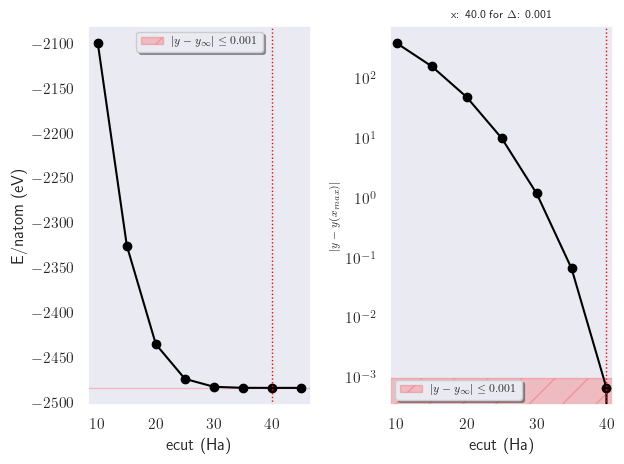

In [26]:
from abipy.tools.plotting import ConvergenceAnalyzer

ecut_Ha = table.sort_values("ecut")["ecut"].tolist()
ene_per_atom_eV = (table.sort_values("ecut")["energy"] / len(wlib.gaas_structure())).tolist()

ca = ConvergenceAnalyzer.from_xy_label_vals(
    "ecut (Ha)", ecut_Ha, "E/natom (eV)", ene_per_atom_eV, tols=1e-3)
ca.plot();

There is a way to gather these files from a flow directory, using a "robot" to gather into a pandas dataframe...in case you liked pandas dataframes.

In [20]:
with abilab.GsrRobot.from_dir("flow_gaas_convecut") as robot:
    table = robot.get_dataframe()

table[["ecut", "energy", "pressure"]].sort_values("ecut")

ValueError: top='flow_gaas_convecut': no such directory

If case you get a `ValueError: top='flow_gaas_convecut': no such directory`

`abipy.tools.plotting.ConvergenceAnalyzer` fits/plots a quantity against a
convergence parameter and reports the smallest parameter value for which
the target quantity stays within a given tolerance:

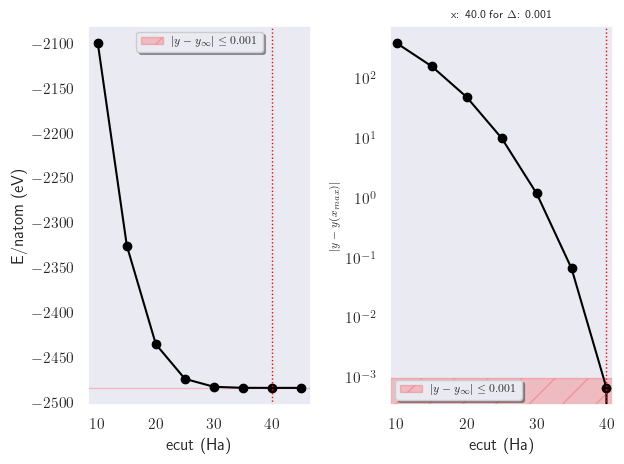

In [12]:
from abipy.tools.plotting import ConvergenceAnalyzer

ecut_Ha = table.sort_values("ecut")["ecut"].tolist()
ene_per_atom_eV = (table.sort_values("ecut")["energy"] / len(wlib.gaas_structure())).tolist()

ca = ConvergenceAnalyzer.from_xy_label_vals(
    "ecut (Ha)", ecut_Ha, "E/natom (eV)", ene_per_atom_eV, tols=1e-3)
ca.plot();

## k-point convergence

Same idea, but now `ecut` is fixed and we vary the k-mesh via
`set_autokmesh(nk)`, which generates an increasingly dense homogeneous
mesh. `gs_input` is the same function shown above.


In [ ]:
wlib.print_source(wlib.build_kpt_conv_flow)

In [ ]:
k_recip_dist, ene_per_atom_eV = [], []

with abilab.GsrRobot.from_dir("flow_gaas_convkpt") as robot:
    for label, gsr in robot:
        ene_per_atom_eV.append(gsr.energy_per_atom)
        rprim = gsr.structure.lattice.matrix
        kptrlatt = gsr.kpoints.ksampling["kptrlatt"]
        R_latt = np.dot(kptrlatt, rprim)
        k_latt = 2 * np.pi * np.linalg.inv(R_latt)
        kmin = max(np.linalg.norm(k) for k in k_latt)
        k_recip_dist.append(1 / kmin)

ca = ConvergenceAnalyzer.from_xy_label_vals(
    "Inverse k-point distance (Ang)", k_recip_dist,
    "E/natom (eV)", ene_per_atom_eV, tols=1e-3)
ca.plot();

> **Exercise.** Redo the ecut convergence study for silicon
> (`wlib.si_structure()`), reusing `wlib.gs_input` as a template: build a
> flow with one SCF task per `ecut`, run it, then analyze it here with a
> `GsrRobot` and `ConvergenceAnalyzer` as above. Is the converged `ecut`
> similar to the one you found for GaAs? Should it be? (This one's also
> waiting for you in `4-Assignment.ipynb` if you'd rather come back to it
> later.)

## 2.2 Relaxation

Rather than fixing the structure and only relaxing the electronic degrees
of freedom (as in every other section of this tutorial), Abinit can also
relax the atomic positions and/or the unit cell itself, driven by the
computed forces and stresses. This is controlled mainly through `ionmov`
(the ionic relaxation algorithm) and `optcell` (whether/how the cell shape
and volume are allowed to change), with convergence controlled by
`tolmxf` (max force) or `tolrff`, instead of the `tolvrs`/`tolwfr` used for
a fixed-geometry SCF run.

Below, we relax AlN (`mp-661`) starting from its experimental (Materials
Project) structure -- already run for you (`flow_aln_relax/`, next to this
notebook). Standalone version: `../Examples/make_aln_relax.py`.


In [ ]:
wlib.print_source(wlib.aln_relax_input)
wlib.print_source(wlib.build_aln_relax_flow)

`ionmov=2` is a Broyden algorithm for the atomic positions; `optcell=1`
additionally lets the cell *volume* relax isotropically (`acell` is
dilated, while `rprim` -- the cell shape -- is left unchanged). Convergence
is judged on the max force (`tolmxf`) rather than the potential residual
(`tolvrs`) used for fixed-geometry runs, and `strfact` rescales the stress
so it's comparable in magnitude to the forces.

`out_HIST.nc`, produced alongside the usual `GSR`, records the structure,
energy, forces and stress at every relaxation step:


In [ ]:
with abilab.abiopen("flow_aln_relax/w0/t0/outdata/out_HIST.nc") as hist:
    hist.plot()
    print("Initial lattice (a, b, c):", hist.initial_structure.lattice.abc)
    print("Relaxed lattice (a, b, c):", hist.final_structure.lattice.abc)

`HistFile` records the whole relaxation trajectory (energy, forces,
stress and the structure itself, at every ionic step) -- `.plot()` above
shows all of it converging, and `.initial_structure`/`.final_structure`
give direct access to the endpoints. There's no `workshop_lib` function
for what comes next -- `../Examples/save_aln_structure.py` is a plain
post-processing script, not a flow builder -- but here's what it does:
grab the *final* relaxed structure from the task's `GSR` file:


In [ ]:
flow = flowtk.Flow.from_file("flow_aln_relax")
task = flow[0][0]                         # the only task of the only Work
gsr_path = task.outdir.has_abiext("GSR")   # retrieve the output GSR file

with abilab.abiopen(gsr_path) as gsr:
    relaxed_structure = gsr.structure

print(relaxed_structure)

`../Examples/save_aln_structure.py` does exactly this, then writes the
result to a standalone `.cif`:

```
cd ../Examples
python save_aln_structure.py
```

writes `Examples/Data/AlN_relaxed.cif` -- the relaxed structure, ready to
be loaded back with `abilab.Structure.from_file(...)` and reused as the
input structure of a later calculation (e.g. a band structure or phonon
flow at the relaxed volume, instead of the experimental one).


## 2.3 Band structure: GaAs

In `1-Task_to_flow.ipynb` we built the band structure of silicon task by
task. Here's the same kind of calculation for GaAs, built in one call with
the higher-level `flowtk.bandstructure_flow` helper (a GS run on a
homogeneous k-mesh, then an NSCF run along a high-symmetry k-path) --
already run for you (`flow_gaas_ebands/`, next to this notebook).
Standalone version: `../Examples/make_gaas_ebands.py`.


In [ ]:
wlib.print_source(wlib._bandstructure_inputs)
wlib.print_source(wlib.build_gaas_ebands_flow)

In [ ]:
with abilab.abiopen("flow_gaas_ebands/w0/t1/outdata/out_GSR.nc") as gsr:
    gaas_ebands = gsr.ebands

fig = gaas_ebands.plot(color="b", show=False)
fig.gca().set_ylim(-10, 10)
fig.gca().set_title("GaAs");

GaAs has a direct gap at $\Gamma$, while silicon's fundamental gap
(Notebook 1) is indirect. This is a good moment to discuss why LDA/GGA
systematically underestimate these gaps, and what the standard corrections
are ($GW$, hybrid functionals, scissor operators).

> **Note.** `ElectronBands` objects also expose `.plot_with_edos(edos)` to
> overlay the density of states next to the bands, and `to_bxsf()` /
> `.plot_fermi_surface()` for metals -- not needed for GaAs/Si, but worth
> knowing about.

## 2.4 Phonons from DFPT

Density-functional perturbation theory (DFPT) gives access to phonons,
Born effective charges and the dielectric tensor without finite
displacements. AbiPy's `PhononFlow` automates the whole workflow: a GS run
that produces the ground-state wavefunctions (`WFK`), followed by one DFPT
task per symmetry-irreducible atomic perturbation and q-point.

`wlib.build_mgo_phonon_flow` builds a simplified, MgO version of this --
coarser `ecut`, k-mesh and q-mesh, for speed -- and has already been run
for you (`flow_mgo_phonons/`, next to this notebook). Standalone version:
`../Examples/make_mgo_phonons.py`. MgO (rocksalt) is strongly ionic, which
makes for a good showcase of the LO-TO splitting below.


In [ ]:
wlib.print_source(wlib.build_mgo_phonon_flow)

All the DFPT results (dynamical matrices, Born effective charges,
dielectric tensor) are merged into a single `DDB` file -- the entry point
for essentially all the post-processing below:


In [ ]:
ddb = abilab.abiopen("flow_mgo_phonons/w1/outdata/out_DDB")
print(ddb)

`ddb.anaget_phbst_and_phdos_files` calls `anaddb` behind the scenes to
Fourier-interpolate the dynamical matrix onto a dense q-mesh (for the
phonon DOS) and along a high-symmetry q-path (for the phonon band
structure) -- this is exactly what `../Examples/run_mgo_anaddb.py` does,
standalone:


In [ ]:
phbst_file, phdos_file = ddb.anaget_phbst_and_phdos_files(
    nqsmall=10, ndivsm=10, asr=2, chneut=1, dipdip=1,
    dos_method="tetra", lo_to_splitting=True)

phbands = phbst_file.phbands
phbands.plot_with_phdos(phdos_file.phdos);

> **Note.** `lo_to_splitting=True` accounts for the LO-TO splitting at
> $\Gamma$ that polar materials like MgO show, using the Born effective
> charges and the dielectric tensor also stored in the `DDB`.

Born effective charges and the dielectric tensor can be inspected directly:


In [ ]:
epsinf, becs = ddb.anaget_epsinf_and_becs()
print("Electronic dielectric tensor:\n", epsinf)
print("\nBorn effective charges:")
print(becs)

Keep `phdos_file` open for now -- `4-Assignment.ipynb` uses it for a
harmonic-thermodynamics exercise. Otherwise, remember to close what you
open:


In [ ]:
phbst_file.close()
ddb.close()

Continue with [`3-Command_line_interface.ipynb`](3-Command_line_interface.ipynb).